In [1]:
print("WELCOME TO UTERINE CANCER REPORT")

# %%
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTEN
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    mean_squared_error,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import shap

WELCOME TO UTERINE CANCER REPORT


In [3]:
df = pd.read_csv("UterineCancer.csv")
print("Shape of data:", df.shape)
print(df.info())
print(df.describe())
df = df.drop(columns=[
    "Patient ID",
    "Sample ID",
    "Cancer Type Detailed",
    "Disease Free Status",
    "Disease-specific Survival status",
])
df["Target"] = df["Overall Survival Status"].str[0].astype(int)
df = df.drop(columns=["Overall Survival Status"])
df = df.dropna()
print("\nShape after dropping missing rows:", df.shape)
feature_cols = [
    "Mutation Count",
    "Fraction Genome Altered",
    "Diagnosis Age",
    "MSI MANTIS Score",
    "MSIsensor Score",
    "Race Category",
    "Subtype",
    "Tumor Type"]
print("\nClass balance (0 = Living, 1 = Deceased):")
print(df["Target"].value_counts())


Shape of data: (529, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529 entries, 0 to 528
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient ID                        529 non-null    object 
 1   Sample ID                         529 non-null    object 
 2   Cancer Type Detailed              529 non-null    object 
 3   Overall Survival Status           529 non-null    object 
 4   Disease Free Status               414 non-null    object 
 5   Disease-specific Survival status  527 non-null    object 
 6   Mutation Count                    515 non-null    float64
 7   Fraction Genome Altered           519 non-null    float64
 8   Diagnosis Age                     526 non-null    float64
 9   MSI MANTIS Score                  526 non-null    float64
 10  MSIsensor Score                   528 non-null    float64
 11  Race Category                     497 non-null

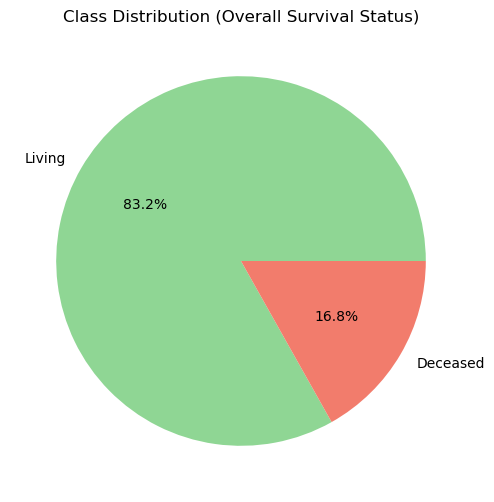

In [4]:
plt.figure(figsize=(6, 6))
df["Target"].value_counts().rename({0: "Living", 1: "Deceased"}).plot.pie(
    autopct="%1.1f%%",
    colors=["#8FD694", "#F27C6C"]
)
plt.title("Class Distribution (Overall Survival Status)")
plt.ylabel("")
plt.savefig("pie_chart.png")
plt.show()
plt.close()

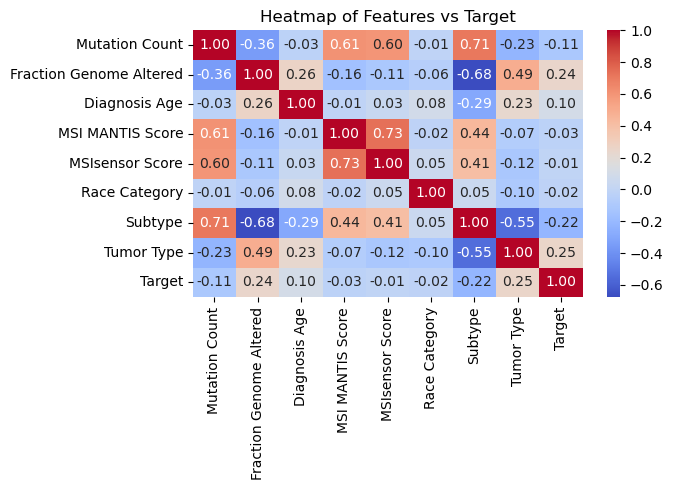

Train shape before SMOTEN: (375, 8) [312  63]
Train shape after SMOTEN: (624, 8) [312 312]
Train shape before SMOTEN: (375, 8) [312  63]


In [7]:
numeric_cols = ["Mutation Count", "Fraction Genome Altered", "Diagnosis Age",
                 "MSI MANTIS Score", "MSIsensor Score"]
categorical_cols = ["Race Category", "Subtype", "Tumor Type"]

df_enc = df.copy()

for col in numeric_cols:
    df_enc[col] = pd.qcut(df_enc[col], q=4, labels=False, duplicates="drop")

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

# %%
plt.figure(figsize=(7, 5))
sns.heatmap(df_enc[feature_cols + ["Target"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of Features vs Target")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()
plt.close()

# %%
X = df_enc[feature_cols]
y = df_enc["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Balance the training data using SMOTEN (categorical-data version of SMOTE)
smoten = SMOTEN(random_state=42)
X_train_bal, y_train_bal = smoten.fit_resample(X_train, y_train)

print("Train shape before SMOTEN:", X_train.shape, np.bincount(y_train))
print("Train shape after SMOTEN:", X_train_bal.shape, np.bincount(y_train_bal))

# %%
print("Train shape before SMOTEN:", X_train.shape, np.bincount(y_train))

In [8]:
model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    enable_categorical=False   # our features are plain integers, not pandas "category" dtype
)
model_xgb.fit(X_train_bal, y_train_bal)
y_pred_xgb = model_xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb, average="macro")
f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print("XGBoost Results")
print("Accuracy:", acc_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)
print("MSE:", mse_xgb)
print(classification_report(y_test, y_pred_xgb, target_names=["Living", "Deceased"]))


XGBoost Results
Accuracy: 0.7021276595744681
Recall: 0.5224358974358974
F1 Score: 0.5190058479532164
MSE: 0.2978723404255319
              precision    recall  f1-score   support

      Living       0.84      0.79      0.82        78
    Deceased       0.20      0.25      0.22        16

    accuracy                           0.70        94
   macro avg       0.52      0.52      0.52        94
weighted avg       0.73      0.70      0.71        94



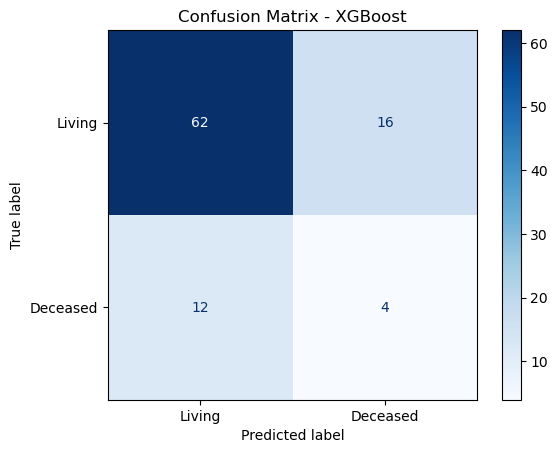

In [9]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Living", "Deceased"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

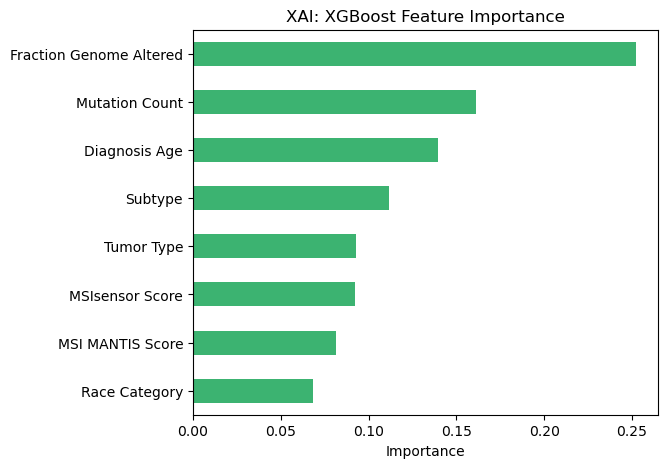

In [10]:
importances = pd.Series(model_xgb.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(6, 5))
importances.plot.barh(color="mediumseagreen")
plt.title("XAI: XGBoost Feature Importance")
plt.xlabel("Importance")
plt.savefig("xai_xgb_importance.png")
plt.show()
plt.close()

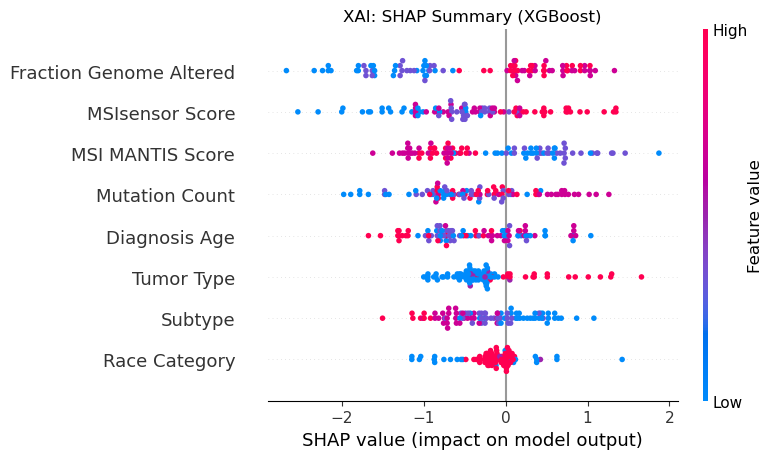

In [11]:
explainer = shap.Explainer(model_xgb, X_train_bal, feature_names=feature_cols)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("XAI: SHAP Summary (XGBoost)")
plt.tight_layout()
plt.savefig("xai_shap_summary.png")
plt.show()
plt.close()